# Retail Demand Forecasting

**Objective:** Forecast daily unit demand with chronological validation, calendar signals, promotions, and a naive baseline.

The notebook uses a deterministic demo series and chronological validation. Metrics are illustrative, not claims about a real retailer or utility.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the time-indexed demo dataset


In [2]:
N_DAYS = 900
data = pd.DataFrame({"date": pd.date_range("2024-01-01", periods=N_DAYS, freq="D")})
data["day_of_year"] = data["date"].dt.dayofyear
data["day_of_week"] = data["date"].dt.dayofweek
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)
data['promotion_pct'] = np.where(rng.random(N_DAYS) < 0.22, rng.choice([5, 10, 15, 20], N_DAYS), 0)
data["units_sold"] = 115 + 2.7 * data['promotion_pct'] - 18 * data['is_weekend'] + 24 * np.sin(2 * np.pi * data['day_of_year'] / 365) + rng.normal(0, 10, N_DAYS)
data["lag_1"] = data["units_sold"].shift(1)
data["lag_7"] = data["units_sold"].shift(7)
data["rolling_7"] = data["units_sold"].shift(1).rolling(7).mean()
data = data.dropna().reset_index(drop=True)
print(f"Series range: {data['date'].min().date()} to {data['date'].max().date()}")
print(f"Usable observations: {len(data):,}")
display(data.head())


Series range: 2024-01-08 to 2026-06-18
Usable observations: 893


,date,day_of_year,day_of_week,is_weekend,promotion_pct,units_sold,lag_1,lag_7,rolling_7
0,2024-01-08,8,0,0,0,103.444136,103.645437,123.458824,117.876278
1,2024-01-09,9,1,0,5,144.107547,103.444136,109.074979,115.017037
2,2024-01-10,10,2,0,0,111.505947,144.107547,120.278412,120.021690
3,2024-01-11,11,3,0,0,113.909899,111.505947,122.305862,118.768481
4,2024-01-12,12,4,0,0,119.700030,113.909899,148.925414,117.569057


## 3. Time-series exploration


,count,mean,min,25%,50%,75%,max,std
date,893,2025-03-29 00:00:00,2024-01-08 00:00:00,2024-08-18 00:00:00,2025-03-29 00:00:00,2025-11-07 00:00:00,2026-06-18 00:00:00,NaN
day_of_year,893.0,166.06159,1.0,77.0,152.0,254.0,366.0,104.187652
day_of_week,893.0,2.993281,0.0,1.0,3.0,5.0,6.0,2.000549
is_weekend,893.0,0.284434,0.0,0.0,0.0,1.0,1.0,0.451397
promotion_pct,893.0,2.917133,0.0,0.0,0.0,0.0,20.0,5.940273
units_sold,893.0,120.045407,59.055292,100.985734,120.246415,137.655463,216.372895,26.749342
lag_1,893.0,120.017652,59.055292,100.985734,120.156072,137.655463,216.372895,26.753489
lag_7,893.0,119.960562,59.055292,100.985734,120.156072,137.585863,216.372895,26.706118
rolling_7,893.0,119.985868,77.382003,103.060193,123.207756,135.369324,163.876314,19.430773


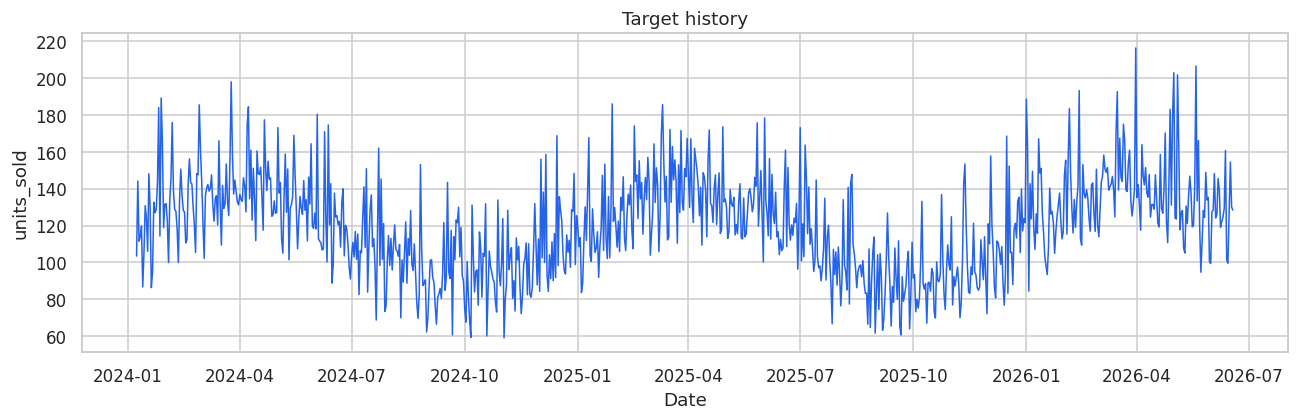

In [3]:
display(data.describe(include="all").T.round(3))
plt.figure(figsize=(12, 4))
plt.plot(data["date"], data["units_sold"], color="#2563eb", linewidth=1)
plt.title("Target history")
plt.xlabel("Date")
plt.ylabel("units_sold")
plt.tight_layout()
plt.show()


## 4. Chronological split and time-aware validation


In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = ["day_of_year", "day_of_week", "is_weekend", "promotion_pct", "lag_1", "lag_7", "rolling_7"]
TARGET = "units_sold"
split_at = int(len(data) * 0.80)
train, test = data.iloc[:split_at], data.iloc[split_at:]
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Ridge Regression": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=2.0))]),
    "Random Forest": RandomForestRegressor(n_estimators=180, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1),
}
cv = TimeSeriesSplit(n_splits=5)
comparison = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=1)
    comparison.append({"model": name, "cv_mae": -scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_mae").reset_index(drop=True)
display(comparison.round(3))


,model,cv_mae,cv_std
0,Random Forest,12.290,5.146
1,Ridge Regression,13.583,7.985
2,Mean baseline,24.830,4.389


## 5. Holdout forecast and baseline comparison


,model,MAE,RMSE,R2
0,Seasonal lag-7 baseline,21.013,28.517,-0.649
1,Random Forest,9.094,12.084,0.704


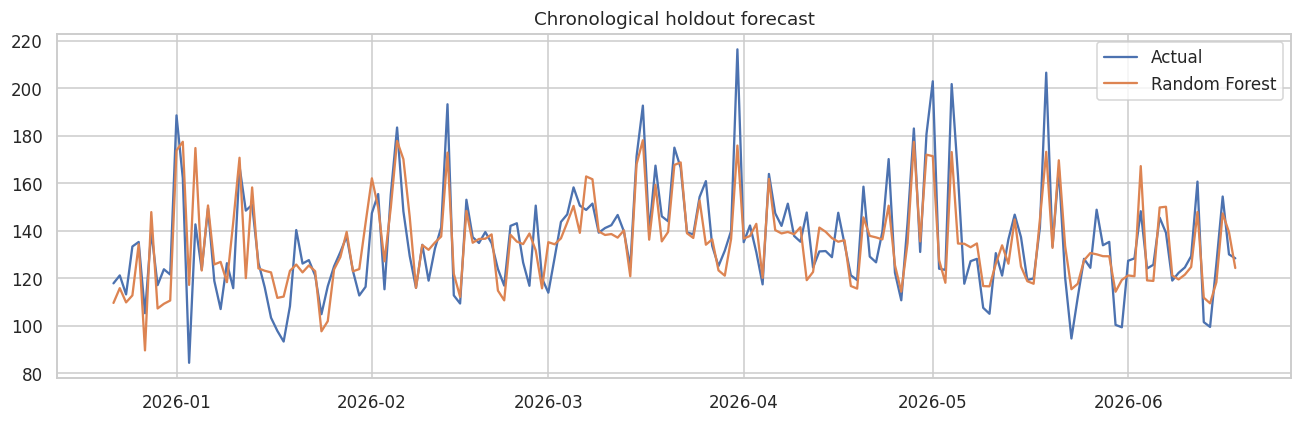

In [5]:
best_name = comparison.iloc[0]["model"]
best_model = models[best_name].fit(X_train, y_train)
predictions = best_model.predict(X_test)
naive = X_test["lag_7"].to_numpy()
results = pd.DataFrame({
    "model": ["Seasonal lag-7 baseline", best_name],
    "MAE": [mean_absolute_error(y_test, naive), mean_absolute_error(y_test, predictions)],
    "RMSE": [mean_squared_error(y_test, naive) ** 0.5, mean_squared_error(y_test, predictions) ** 0.5],
    "R2": [r2_score(y_test, naive), r2_score(y_test, predictions)],
})
display(results.round(3))

forecast = test[["date", TARGET]].copy()
forecast["prediction"] = predictions
plt.figure(figsize=(12, 4))
plt.plot(forecast["date"], forecast[TARGET], label="Actual")
plt.plot(forecast["date"], forecast["prediction"], label=best_name)
plt.title("Chronological holdout forecast")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Operational interpretation and next steps

- Replace demo observations with a versioned real series and document missing dates, revisions, and outliers.
- Compare against stronger seasonal baselines and use rolling-origin backtesting across several horizons.
- Add forecast intervals, holiday/event features, drift alerts, and cost-weighted service metrics.
- Never use random train/test splits for this time-ordered problem.
